# Notebook 1 — Análise Exploratória e Seleção de Features

**Objetivo:** Carregar os dados brutos de treino e teste, realizar limpeza básica (sem remoção de outliers), avaliar a distribuição das variáveis, analisar correlações com o preço e aplicar ANOVA para decidir quais features devem ser mantidas no treinamento.

**Saída:** `database/train_processed.csv` e `database/test_processed.csv` com os dados tratados e prontos para o Notebook 2.

In [1]:
# Instalar dependências caso não estejam presentes
import subprocess, sys
pkgs = ["seaborn", "xgboost", "lightgbm"]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)
print("Dependências OK")

Dependências OK


## 1. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata
import os

from scipy import stats
from scipy.stats import pointbiserialr, f_oneway
from sklearn.feature_selection import f_regression

sns.set_theme(style='whitegrid')
os.makedirs('database', exist_ok=True)
print('Imports concluídos.')

Imports concluídos.


## 2. Carregamento dos dados

In [3]:
df_train = pd.read_csv('database/train_mod.csv')
df_test  = pd.read_csv('database/test.csv')

print(f'Treino : {df_train.shape[0]:,} linhas × {df_train.shape[1]} colunas')
print(f'Teste  : {df_test.shape[0]:,} linhas × {df_test.shape[1]} colunas')
df_train.head()

Treino : 8,685 linhas × 26 colunas
Teste  : 17,370 linhas × 26 colunas


,ID,Débitos,Fabricante,Modelo,Ano,Categoria,Couro,Combustivel,Volume_motor,Km,...,Airbags,Preco,Numero_proprietarios,Data_ultima_lavagem,Adesivos_personalizados,Radio_AM_FM,Historico_troca_oleo,Codigo_concessionaria,Classificacao_Veiculo,Faixa_Preco
0,45654403,1399,LEXUS,RX 450,2010,SUV,Sim,Hibrido,3.5,186005 km,...,12,13328.0,1,2021-03-14,Sim,FM,8,8497,Usado,Econômico
1,44731507,1018,CHEVROLET,Equinox,2011,SUV,Nao,GASOLINA,3,NaN,...,8,16621.0,5,2021-08-08,Sim,AM,4,6796,Usado,Econômico
2,45774419,-,HONDA,FIT,2006,Hatchback,Nao,GASOLINA,1.3,200000 km,...,2,8467.0,1,2020-04-14,Sim,FM,5,3382,Usado,Econômico
3,45769185,862,FORD,Escape,2011,SUV,Sim,Hibrido,2.5,168966 km,...,0,3607.0,1,2020-01-13,Não,AM/FM,7,1458,Usado,Econômico
4,45809263,446,HONDA,FIT,2014,Hatchback,Sim,Gasolina,1.3,91901 km,...,4,11726.0,2,2021-10-11,Não,AM,5,5374,Usado,Econômico


## 3. Visão geral das colunas

In [4]:
print('=== COLUNAS ===')
for col in df_train.columns:
    dtype  = df_train[col].dtype
    nulls  = df_train[col].isna().sum()
    unique = df_train[col].nunique()
    print(f'  {col:<35} dtype={str(dtype):<10} nulos={nulls:<6} únicos={unique}')

=== COLUNAS ===
  ID                                  dtype=int64      nulos=0      únicos=8593
  Débitos                             dtype=str        nulos=0      únicos=436
  Fabricante                          dtype=str        nulos=0      únicos=60
  Modelo                              dtype=str        nulos=0      únicos=1032
  Ano                                 dtype=int64      nulos=0      únicos=46
  Categoria                           dtype=str        nulos=0      únicos=11
  Couro                               dtype=str        nulos=0      únicos=2
  Combustivel                         dtype=str        nulos=0      únicos=10
  Volume_motor                        dtype=str        nulos=0      únicos=96
  Km                                  dtype=str        nulos=870    únicos=3745
  Cilindros                           dtype=int64      nulos=0      únicos=13
  Tipo_cambio                         dtype=str        nulos=0      únicos=4
  Tração                              dtype

In [5]:
print('\n=== ESTATÍSTICAS DESCRITIVAS ===')
df_train.describe(include='all').T


=== ESTATÍSTICAS DESCRITIVAS ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,8685.0,NaN,NaN,NaN,45571465.882096,924902.290232,24701923.0,45689444.0,45771752.0,45801649.0,45816654.0
Débitos,8685,436,-,2638,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fabricante,8685,60,TOYOTA,1794,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Modelo,8685,1032,Prius,507,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ano,8685.0,NaN,NaN,NaN,2010.830397,5.66295,1943.0,2009.0,2012.0,2014.0,2020.0
Categoria,8685,11,Sedan,3826,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Couro,8685,2,Sim,6192,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Combustivel,8685,10,Gasolina,1966,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Volume_motor,8685,96,2,1556,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Km,7815,3745,0 km,295,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Limpeza e padronização de tipos

> **Nota:** Nesta etapa NÃO são removidos outliers. O objetivo é apenas garantir tipos corretos e padronizar categorias.

In [6]:
def normalizar_texto(texto):
    """Remove acentos, strips e lowercase."""
    if pd.isna(texto):
        return texto
    texto = str(texto).strip().lower()
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )
    return texto


MAPEAMENTO_COMBUSTIVEL = {
    'gasolina'   : 'Gasolina',
    'gasol.'     : 'Gasolina',
    'diesel'     : 'Diesel',
    'dies.'      : 'Diesel',
    'hibrido'    : 'Híbrido',
    'gas natural': 'Gás Natural',
    'eletrico'   : 'Elétrico',
}


def limpar_dataset(df: pd.DataFrame) -> pd.DataFrame:
    """Aplica limpeza e padronização de tipos sem remover outliers."""
    df = df.copy()

    # --- Combustível ---
    if 'Combustivel' in df.columns:
        df['Combustivel'] = (
            df['Combustivel']
            .apply(normalizar_texto)
            .map(MAPEAMENTO_COMBUSTIVEL)
            .fillna(df['Combustivel'])
        )

    # --- Volume do motor ---
    if 'Volume_motor' in df.columns:
        df['Volume_motor'] = (
            df['Volume_motor']
            .astype(str).str.strip()
            .str.replace(',', '.', regex=False)
            .str.extract(r'(\d+(?:\.\d+)?)')[0]
        )
        df['Volume_motor'] = pd.to_numeric(df['Volume_motor'], errors='coerce')

    # --- Km ---
    if 'Km' in df.columns:
        df['Km'] = (
            df['Km'].astype(str).str.lower()
            .str.replace('km', '', regex=False)
            .str.replace('.', '', regex=False)
            .str.replace(',', '', regex=False)
            .str.strip()
        )
        df['Km'] = pd.to_numeric(df['Km'], errors='coerce')

    # --- Débitos ---
    if 'Débitos' in df.columns:
        df['Débitos'] = pd.to_numeric(
            df['Débitos'].astype(str).str.replace('-', '0', regex=False),
            errors='coerce'
        ).fillna(0)

    return df


df_train = limpar_dataset(df_train)
df_test  = limpar_dataset(df_test)

print('Limpeza concluída.')
print(f'Tipos após limpeza:')
print(df_train.dtypes)

Limpeza concluída.
Tipos após limpeza:
ID                           int64
Débitos                      int64
Fabricante                     str
Modelo                         str
Ano                          int64
Categoria                      str
Couro                          str
Combustivel                    str
Volume_motor               float64
Km                         float64
Cilindros                    int64
Tipo_cambio                    str
Tração                         str
Portas                         str
Rodas                        int64
Cor                            str
Airbags                      int64
Preco                      float64
Numero_proprietarios         int64
Data_ultima_lavagem            str
Adesivos_personalizados        str
Radio_AM_FM                    str
Historico_troca_oleo         int64
Codigo_concessionaria        int64
Classificacao_Veiculo          str
Faixa_Preco                    str
dtype: object


## 5. Distribuição da variável alvo (Preço)

Visualização sem remoção de outliers — serve para entender a assimetria da distribuição.

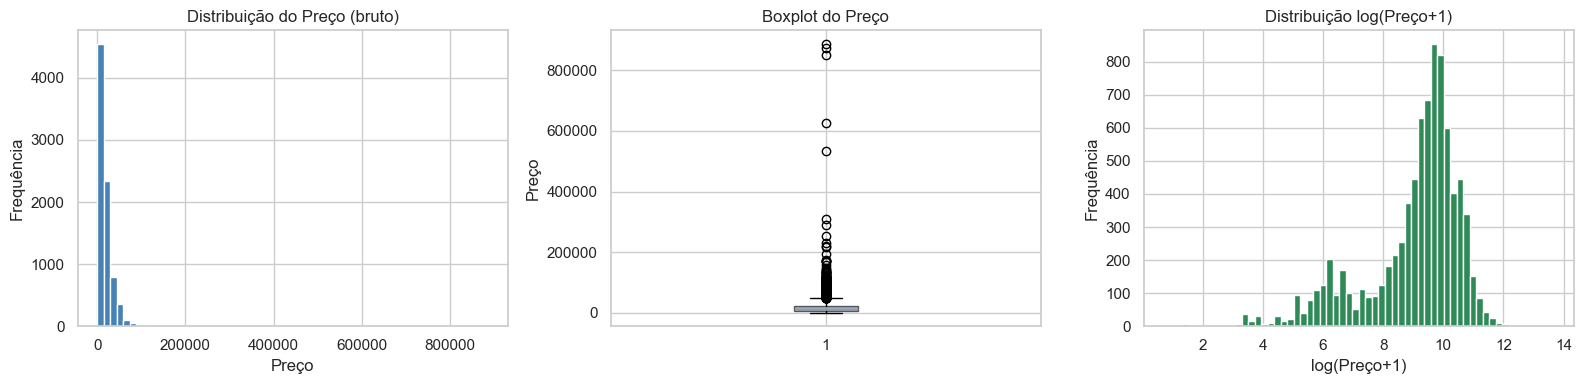

Estatísticas do Preço:
count      8261.00
mean      17700.68
std       26383.54
min           1.00
25%        4861.00
50%       13172.00
75%       22825.00
max      886993.00
Name: Preco, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histograma
axes[0].hist(df_train['Preco'].dropna(), bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição do Preço (bruto)')
axes[0].set_xlabel('Preço')
axes[0].set_ylabel('Frequência')

# Boxplot
axes[1].boxplot(df_train['Preco'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot do Preço')
axes[1].set_ylabel('Preço')

# Log-transformado
log_preco = np.log1p(df_train['Preco'].dropna())
axes[2].hist(log_preco, bins=60, color='seagreen', edgecolor='white')
axes[2].set_title('Distribuição log(Preço+1)')
axes[2].set_xlabel('log(Preço+1)')
axes[2].set_ylabel('Frequência')

plt.tight_layout()
plt.savefig('distribuicao_preco.png', dpi=150)
plt.show()

print('Estatísticas do Preço:')
print(df_train['Preco'].describe().round(2))

## 6. Análise de nulos

Colunas com valores nulos:
             Nulos  Percentual (%)
Km             870           10.02
Preco          424            4.88
Faixa_Preco    424            4.88


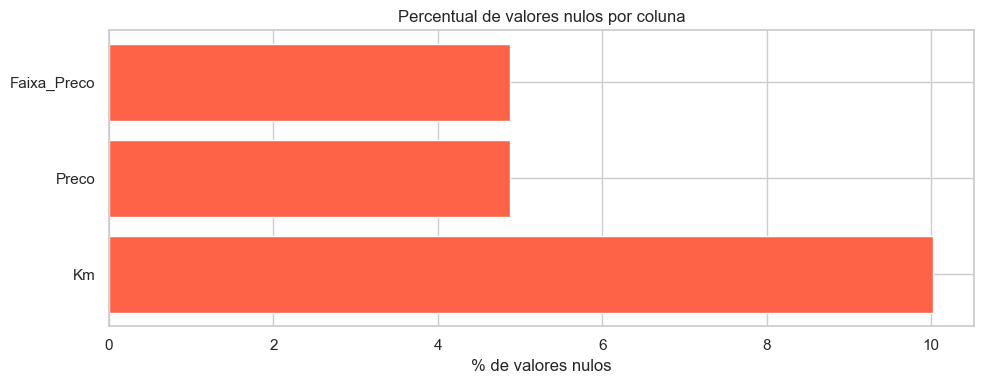

In [8]:
nulos = df_train.isna().sum().sort_values(ascending=False)
nulos_pct = (nulos / len(df_train) * 100).round(2)

df_nulos = pd.DataFrame({'Nulos': nulos, 'Percentual (%)': nulos_pct})
df_nulos = df_nulos[df_nulos['Nulos'] > 0]

print('Colunas com valores nulos:')
print(df_nulos.to_string())

# Gráfico
if len(df_nulos) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(df_nulos.index, df_nulos['Percentual (%)'], color='tomato')
    ax.set_xlabel('% de valores nulos')
    ax.set_title('Percentual de valores nulos por coluna')
    plt.tight_layout()
    plt.savefig('nulos_por_coluna.png', dpi=150)
    plt.show()

## 7. Análise de variáveis categóricas vs Preço

In [9]:
cat_cols = df_train.select_dtypes(include='object').columns.tolist()
# Excluir identificadores óbvios
cat_cols = [c for c in cat_cols if c not in ['ID', 'Modelo']]

print(f'Colunas categóricas a analisar: {cat_cols}\n')

for col in cat_cols:
    n_unique = df_train[col].nunique()
    print(f'--- {col} ({n_unique} categorias) ---')
    print(df_train[col].value_counts().head(10))
    print()

Colunas categóricas a analisar: ['Fabricante', 'Categoria', 'Couro', 'Combustivel', 'Tipo_cambio', 'Tração', 'Portas', 'Cor', 'Data_ultima_lavagem', 'Adesivos_personalizados', 'Radio_AM_FM', 'Classificacao_Veiculo', 'Faixa_Preco']

--- Fabricante (60 categorias) ---
Fabricante
TOYOTA           1794
HYUNDAI          1496
MERCEDES-BENZ     939
FORD              507
BMW               483
HONDA             469
CHEVROLET         468
LEXUS             460
NISSAN            275
VOLKSWAGEN        250
Name: count, dtype: int64

--- Categoria (11 categorias) ---
Categoria
Sedan             3826
SUV               2555
Hatchback         1314
Minivan            285
Cupê               261
Universal          156
Microonibus        127
Vagao de carga     115
Picape              23
Conversivel         17
Name: count, dtype: int64

--- Couro (2 categorias) ---
Couro
Sim    6192
Nao    2493
Name: count, dtype: int64

--- Combustivel (4 categorias) ---
Combustivel
Gasolina       4902
Diesel         1841
H

C:\Users\Lucas\AppData\Local\Temp\ipykernel_21964\1331903351.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_train.select_dtypes(include='object').columns.tolist()


C:\Users\Lucas\AppData\Local\Temp\ipykernel_21964\32485981.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(grupos, labels=df_train[col].dropna().unique(),
C:\Users\Lucas\AppData\Local\Temp\ipykernel_21964\32485981.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(grupos, labels=df_train[col].dropna().unique(),
C:\Users\Lucas\AppData\Local\Temp\ipykernel_21964\32485981.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(grupos, labels=df_train[col].dropna().unique(),
C:\Users\Lucas\AppData\Local\Temp\ipykernel_21964\32485981.py:12: MatplotlibDeprecationWarning: T

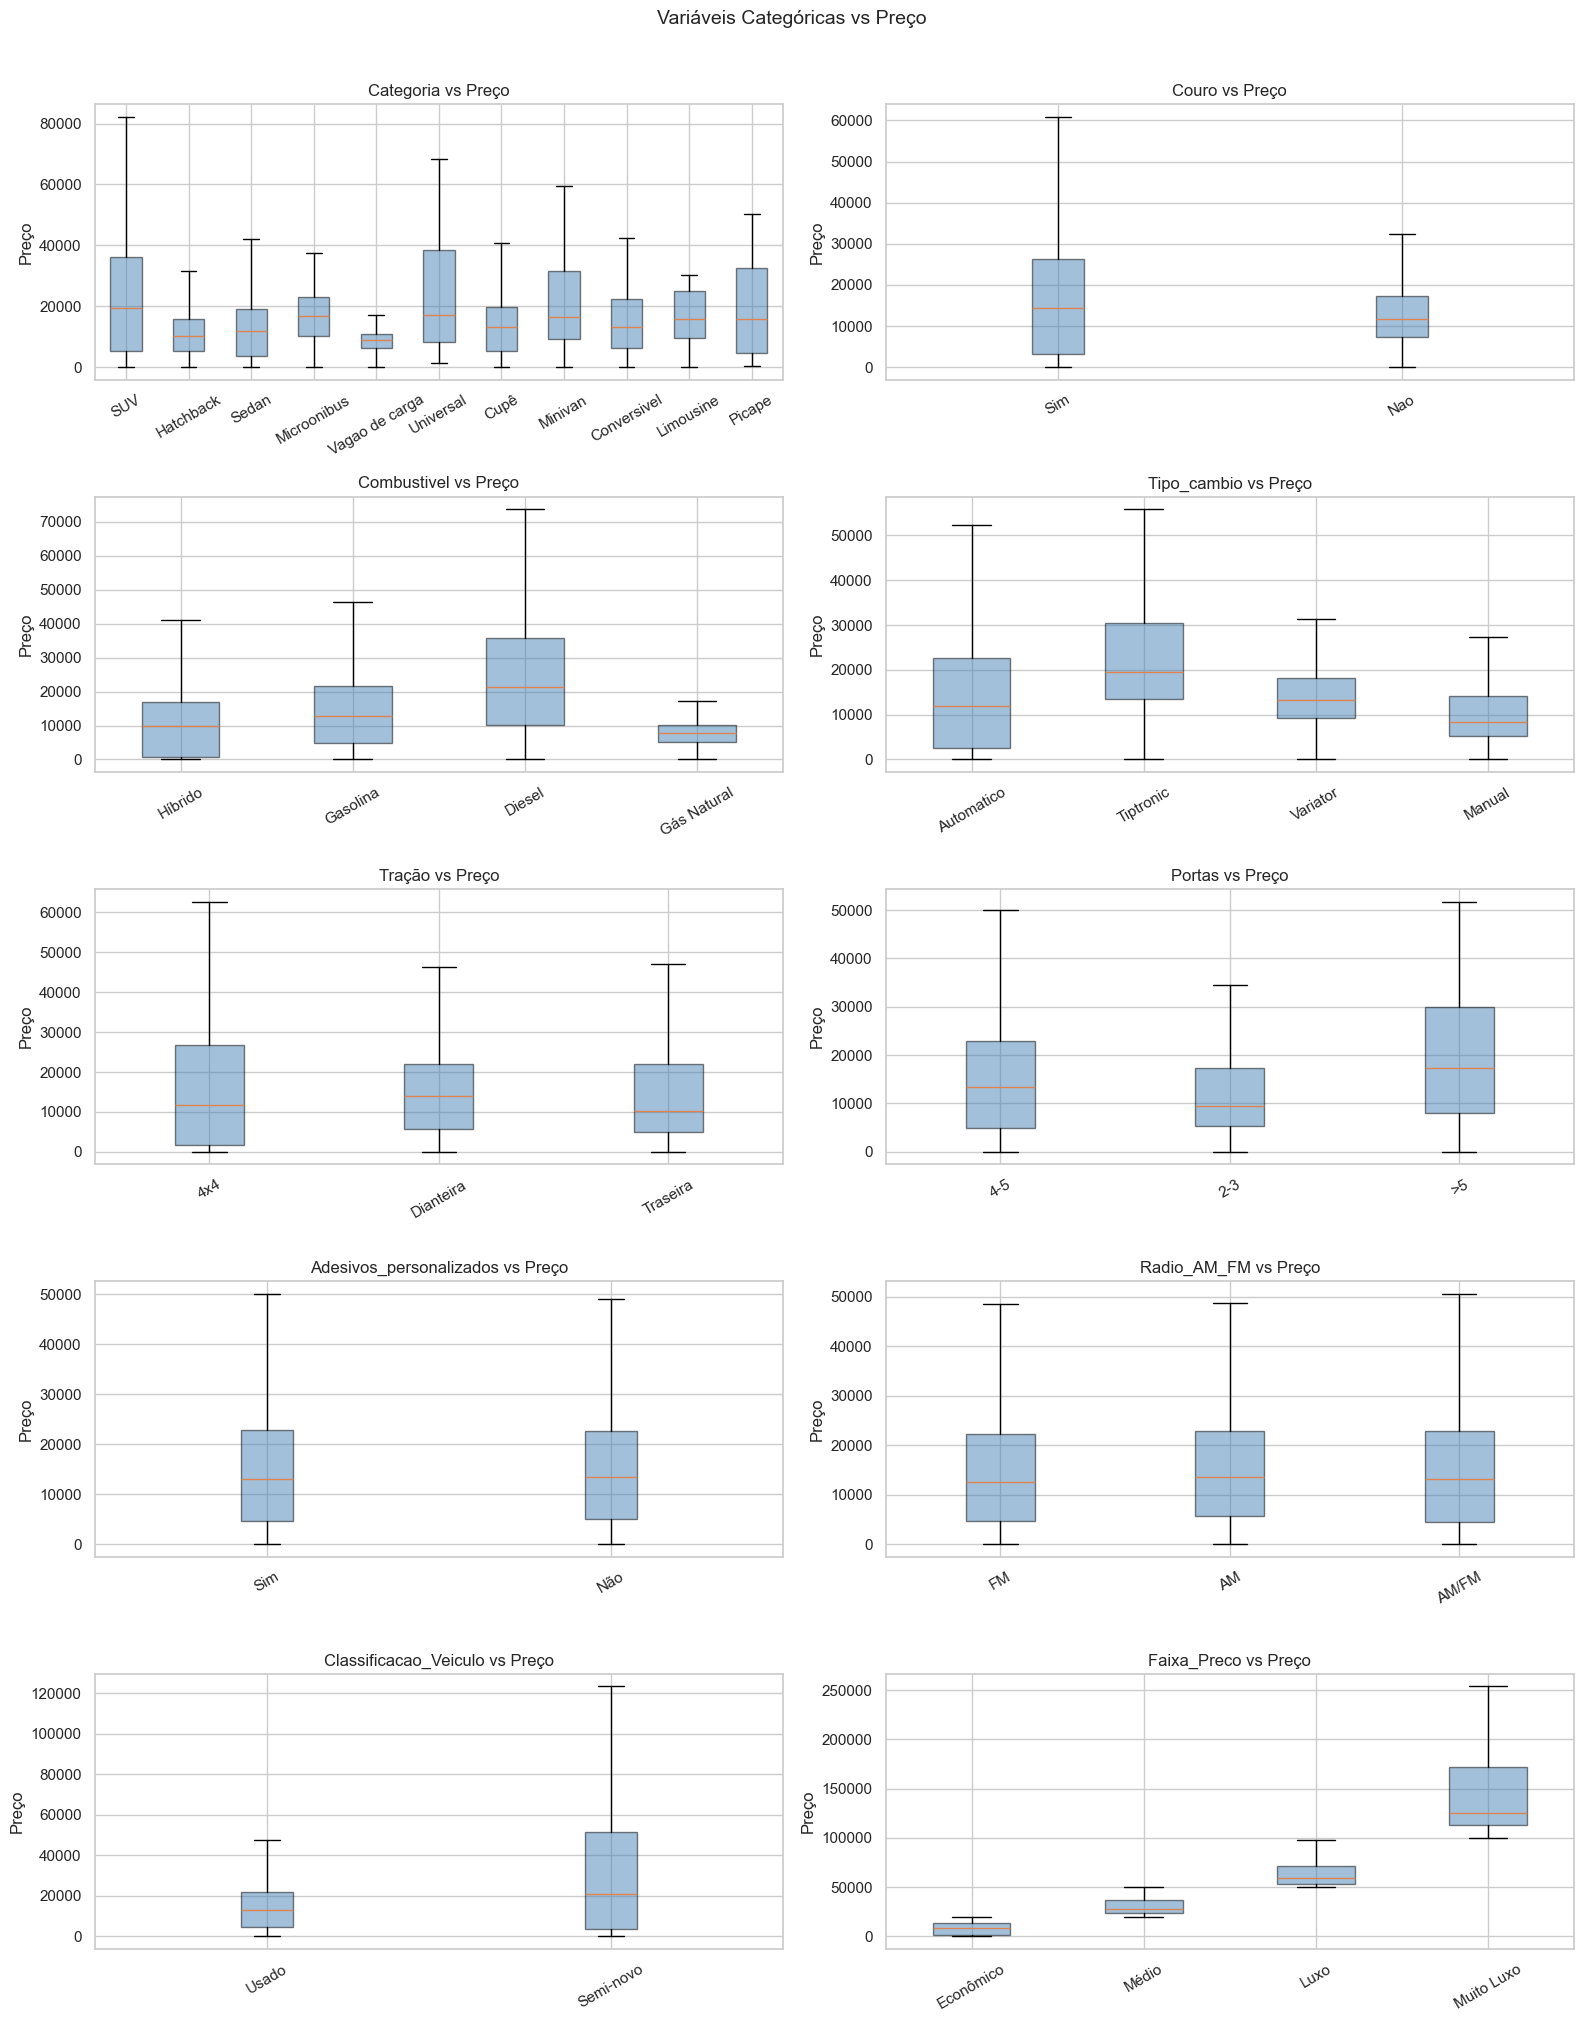

In [10]:
# Boxplots para categóricas com poucas categorias
cat_plot = [c for c in cat_cols if df_train[c].nunique() <= 15]

n_cols = 2
n_rows = int(np.ceil(len(cat_plot) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_plot):
    grupos = [df_train.loc[df_train[col] == v, 'Preco'].dropna()
              for v in df_train[col].dropna().unique()]
    axes[i].boxplot(grupos, labels=df_train[col].dropna().unique(),
                    showfliers=False, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.5))
    axes[i].set_title(f'{col} vs Preço')
    axes[i].set_ylabel('Preço')
    axes[i].tick_params(axis='x', rotation=30)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Variáveis Categóricas vs Preço', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('categoricas_vs_preco.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Correlação de Pearson — variáveis numéricas vs Preço

Correlação de Pearson com Preço:
Ano                      0.207699
Volume_motor             0.131691
Cilindros                0.103025
Débitos                  0.038674
Airbags                 -0.029852
Codigo_concessionaria    0.022922
Numero_proprietarios     0.015480
Rodas                    0.012514
Historico_troca_oleo     0.010483
Km                      -0.010315
ID                      -0.005941


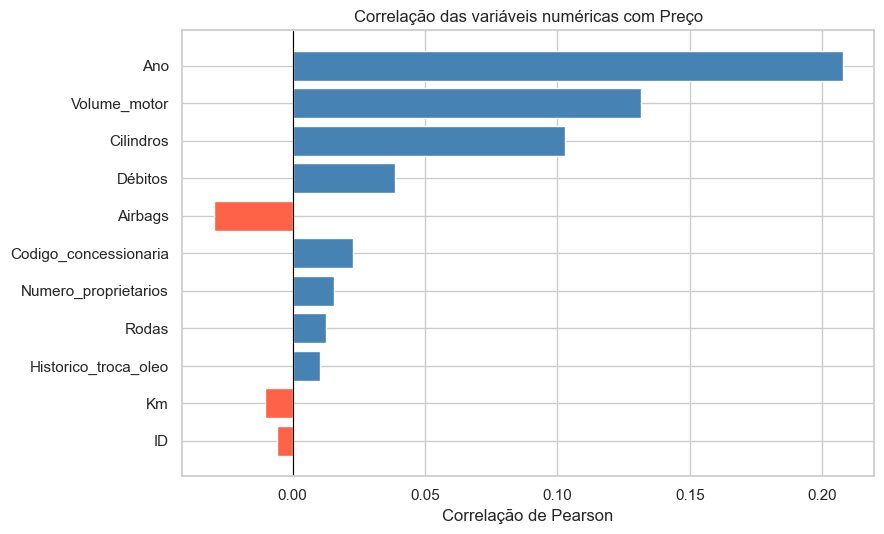

In [11]:
num_cols = df_train.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c != 'Preco']

correlacoes = (
    df_train[num_cols + ['Preco']]
    .corr()['Preco']
    .drop('Preco')
    .sort_values(key=abs, ascending=False)
)

print('Correlação de Pearson com Preço:')
print(correlacoes.to_string())

# Gráfico
fig, ax = plt.subplots(figsize=(9, max(4, len(correlacoes) * 0.5)))
cores = ['steelblue' if v >= 0 else 'tomato' for v in correlacoes]
ax.barh(correlacoes.index[::-1], correlacoes.values[::-1], color=cores[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlação de Pearson')
ax.set_title('Correlação das variáveis numéricas com Preço')
plt.tight_layout()
plt.savefig('correlacao_numericas.png', dpi=150)
plt.show()

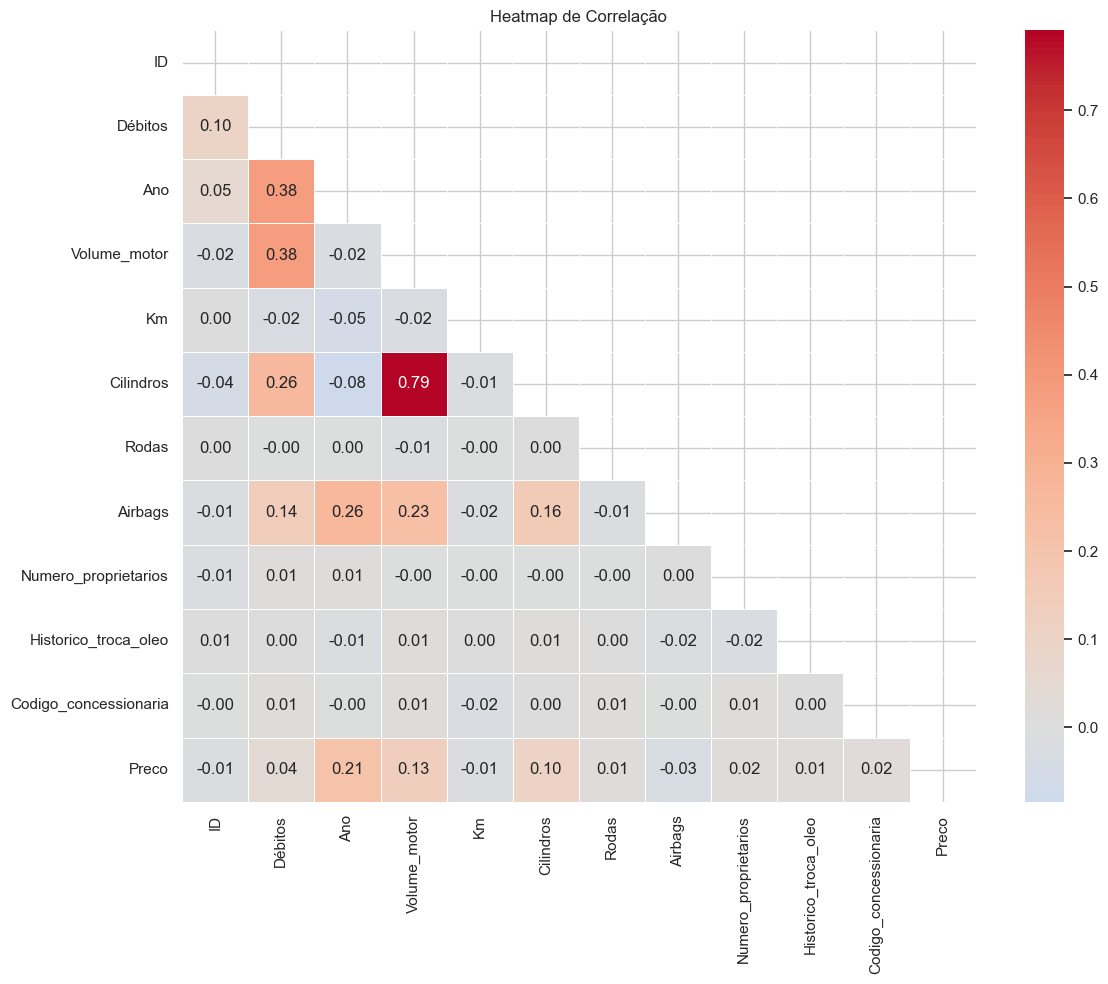

In [12]:
# Heatmap de correlação entre todas as variáveis numéricas
df_num = df_train[num_cols + ['Preco']].select_dtypes(include='number')

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(df_num.corr(), dtype=bool))
sns.heatmap(df_num.corr(), mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
ax.set_title('Heatmap de Correlação')
plt.tight_layout()
plt.savefig('heatmap_correlacao.png', dpi=150)
plt.show()

## 9. Análise de variáveis suspeitas (baixa correlação esperada)

Adesivos_personalizados — corr ponto-bisserial: -0.0042  p=0.6937

=== Correlação com Preço — variáveis suspeitas ===
  Dias_desde_lavagem             +0.0059
  Codigo_concessionaria          +0.0229
  ID                             -0.0059


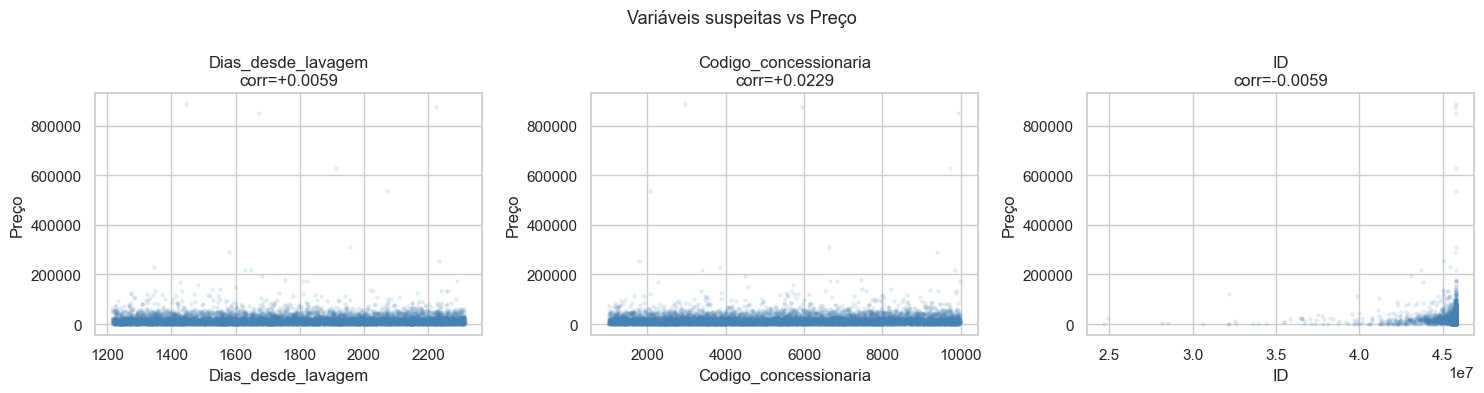

In [13]:
# Data_ultima_lavagem → converter para dias desde hoje
if 'Data_ultima_lavagem' in df_train.columns:
    df_train['Dias_desde_lavagem'] = (
        pd.Timestamp('today') -
        pd.to_datetime(df_train['Data_ultima_lavagem'], errors='coerce')
    ).dt.days

# Adesivos_personalizados → correlação ponto-bisserial
if 'Adesivos_personalizados' in df_train.columns:
    adesivos_bin = (df_train['Adesivos_personalizados'] == 'Sim').astype(int)
    corr_pb, pval_pb = pointbiserialr(
        adesivos_bin, df_train['Preco'].fillna(0)
    )
    print(f'Adesivos_personalizados — corr ponto-bisserial: {corr_pb:+.4f}  p={pval_pb:.4f}')

# Variáveis suspeitas numéricas
suspeitas = {}
if 'Dias_desde_lavagem' in df_train.columns:
    suspeitas['Dias_desde_lavagem'] = df_train['Dias_desde_lavagem']
if 'Codigo_concessionaria' in df_train.columns:
    suspeitas['Codigo_concessionaria'] = pd.to_numeric(
        df_train['Codigo_concessionaria'], errors='coerce')
if 'ID' in df_train.columns:
    suspeitas['ID'] = pd.to_numeric(df_train['ID'], errors='coerce')

print('\n=== Correlação com Preço — variáveis suspeitas ===')
for nome, serie in suspeitas.items():
    corr = serie.corr(df_train['Preco'])
    print(f'  {nome:<30} {corr:+.4f}')

# Scatter
if suspeitas:
    n = len(suspeitas)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, (nome, serie) in zip(axes, suspeitas.items()):
        ax.scatter(serie, df_train['Preco'], alpha=0.1, s=5, color='steelblue')
        ax.set_xlabel(nome)
        ax.set_ylabel('Preço')
        corr = serie.corr(df_train['Preco'])
        ax.set_title(f'{nome}\ncorr={corr:+.4f}')
    plt.suptitle('Variáveis suspeitas vs Preço', fontsize=13)
    plt.tight_layout()
    plt.savefig('suspeitas_vs_preco.png', dpi=150)
    plt.show()

## 10. ANOVA — seleção de features

Aplica o teste F (ANOVA) para avaliar a significância estatística de cada feature em relação ao Preço. Features com p-value > 0.05 serão candidatas à exclusão.

In [14]:
# --- Preparar X para ANOVA ---
COLUNAS_REMOVER_EDA = [
    'ID', 'Faixa_Preco', 'Classificacao_Veiculo', 'Modelo',
    'Data_ultima_lavagem', 'Adesivos_personalizados', 'Codigo_concessionaria',
]

df_anova = df_train.drop(
    columns=[c for c in COLUNAS_REMOVER_EDA if c in df_train.columns]
).dropna(subset=['Preco'])

# Encodar categóricas para ANOVA
df_anova_enc = pd.get_dummies(df_anova, drop_first=True)
X_anova = df_anova_enc.drop(columns=['Preco']).fillna(df_anova_enc.drop(columns=['Preco']).mean())
y_anova = df_anova_enc['Preco']

# Converter bool → int
X_anova = X_anova.astype({c: int for c in X_anova.select_dtypes(include='bool').columns})
X_anova = X_anova.select_dtypes(include='number')

print(f'Features para ANOVA: {X_anova.shape[1]}')
print(f'Amostras           : {len(y_anova)}')

Features para ANOVA: 107
Amostras           : 8261


In [15]:
f_scores, p_values = f_regression(X_anova, y_anova)

df_anova_result = pd.DataFrame({
    'Feature' : X_anova.columns,
    'F_score' : f_scores,
    'p_value' : p_values
}).sort_values('F_score', ascending=False)

print('=== ANOVA — Top 20 features ===')
print(df_anova_result.head(20).to_string(index=False))

=== ANOVA — Top 20 features ===
                Feature     F_score       p_value
 Fabricante_LAMBORGHINI 1203.968877 2.175625e-246
                    Ano  372.346172  3.471619e-81
  Tipo_cambio_Tiptronic  239.627349  2.646874e-53
          Categoria_SUV  230.534459  2.242236e-51
           Volume_motor  145.760803  2.789210e-33
    Combustivel_Híbrido  143.405273  8.945561e-33
     Fabricante_HYUNDAI  139.980979  4.872252e-32
     Fabricante_BENTLEY   94.030551  4.075068e-22
        Categoria_Sedan   90.926463  1.922091e-21
              Cilindros   88.602584  6.143488e-21
              Couro_Sim   85.459874  2.960188e-20
    Categoria_Hatchback   84.424022  4.971918e-20
   Fabricante_SSANGYONG   54.294601  1.892233e-13
     Tipo_cambio_Manual   46.068897  1.220486e-11
      Fabricante_TOYOTA   40.266357  2.332628e-10
  Fabricante_LAND ROVER   39.456681  3.523805e-10
              Cor_Preto   36.775596  1.383644e-09
        Fabricante_OPEL   30.708062  3.091446e-08
Combustivel_Gás Na

In [16]:
# --- Features a REMOVER (p-value > 0.05) ---
ALPHA = 0.05
features_remover = df_anova_result[df_anova_result['p_value'] > ALPHA]['Feature'].tolist()

print(f'\nFeatures NÃO significativas (p > {ALPHA}): {len(features_remover)}')
for f in features_remover:
    pv = df_anova_result.loc[df_anova_result['Feature'] == f, 'p_value'].values[0]
    print(f'  {f:<40} p={pv:.4f}')

features_manter = df_anova_result[df_anova_result['p_value'] <= ALPHA]['Feature'].tolist()
print(f'\nFeatures mantidas: {len(features_manter)}')


Features NÃO significativas (p > 0.05): 63
  Fabricante_FORD                          p=0.0547
  Portas_>5                                p=0.0606
  Fabricante_FIAT                          p=0.0613
  Fabricante_JAGUAR                        p=0.0625
  Fabricante_MERCEDES-BENZ                 p=0.0971
  Cor_Cinza                                p=0.1136
  Categoria_Minivan                        p=0.1219
  Categoria_Picape                         p=0.1334
  Fabricante_SUZUKI                        p=0.1466
  Numero_proprietarios                     p=0.1595
  Fabricante_TESLA                         p=0.1696
  Fabricante_HUMMER                        p=0.1756
  Fabricante_DAIHATSU                      p=0.1787
  Fabricante_CHRYSLER                      p=0.2024
  Cor_Roxo                                 p=0.2137
  Cor_Azul ceu                             p=0.2200
  Rodas                                    p=0.2554
  Fabricante_LEXUS                         p=0.2810
  Fabricante_RENAULT

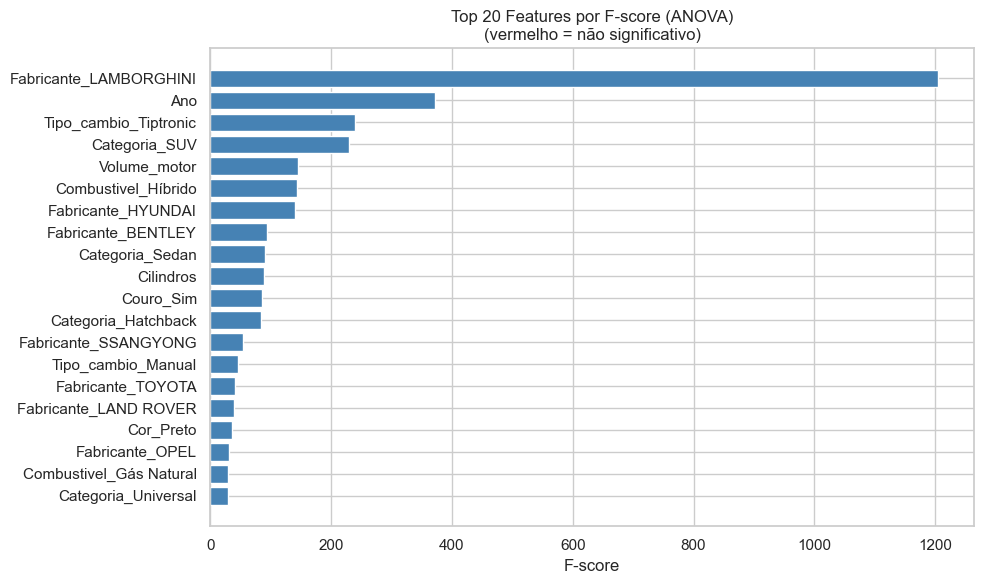

In [17]:
# --- Gráfico Top 20 ANOVA ---
top20 = df_anova_result.head(20)

fig, ax = plt.subplots(figsize=(10, 6))
cores = ['steelblue' if p <= ALPHA else 'tomato' for p in top20['p_value']]
ax.barh(top20['Feature'][::-1], top20['F_score'][::-1], color=cores[::-1])
ax.set_xlabel('F-score')
ax.set_title('Top 20 Features por F-score (ANOVA)\n(vermelho = não significativo)')
plt.tight_layout()
plt.savefig('anova_top20.png', dpi=150)
plt.show()

C:\Users\Lucas\AppData\Local\Temp\ipykernel_21964\3259933495.py:13: UserWarning: Glyph 4321 (\N{GEORGIAN LETTER SAN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Lucas\AppData\Local\Temp\ipykernel_21964\3259933495.py:13: UserWarning: Glyph 4334 (\N{GEORGIAN LETTER XAN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Lucas\AppData\Local\Temp\ipykernel_21964\3259933495.py:13: UserWarning: Glyph 4309 (\N{GEORGIAN LETTER VIN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Lucas\AppData\Local\Temp\ipykernel_21964\3259933495.py:13: UserWarning: Glyph 4304 (\N{GEORGIAN LETTER AN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Lucas\AppData\Local\Temp\ipykernel_21964\3259933495.py:14: UserWarning: Glyph 4321 (\N{GEORGIAN LETTER SAN}) missing from font(s) Arial.
  plt.savefig('anova_pvalues.png', dpi=150)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_21964\3259933495.py:14: UserWarning: Glyph 4334 (\N{GEORGIAN LETTER XAN}) missing from font(s) Aria

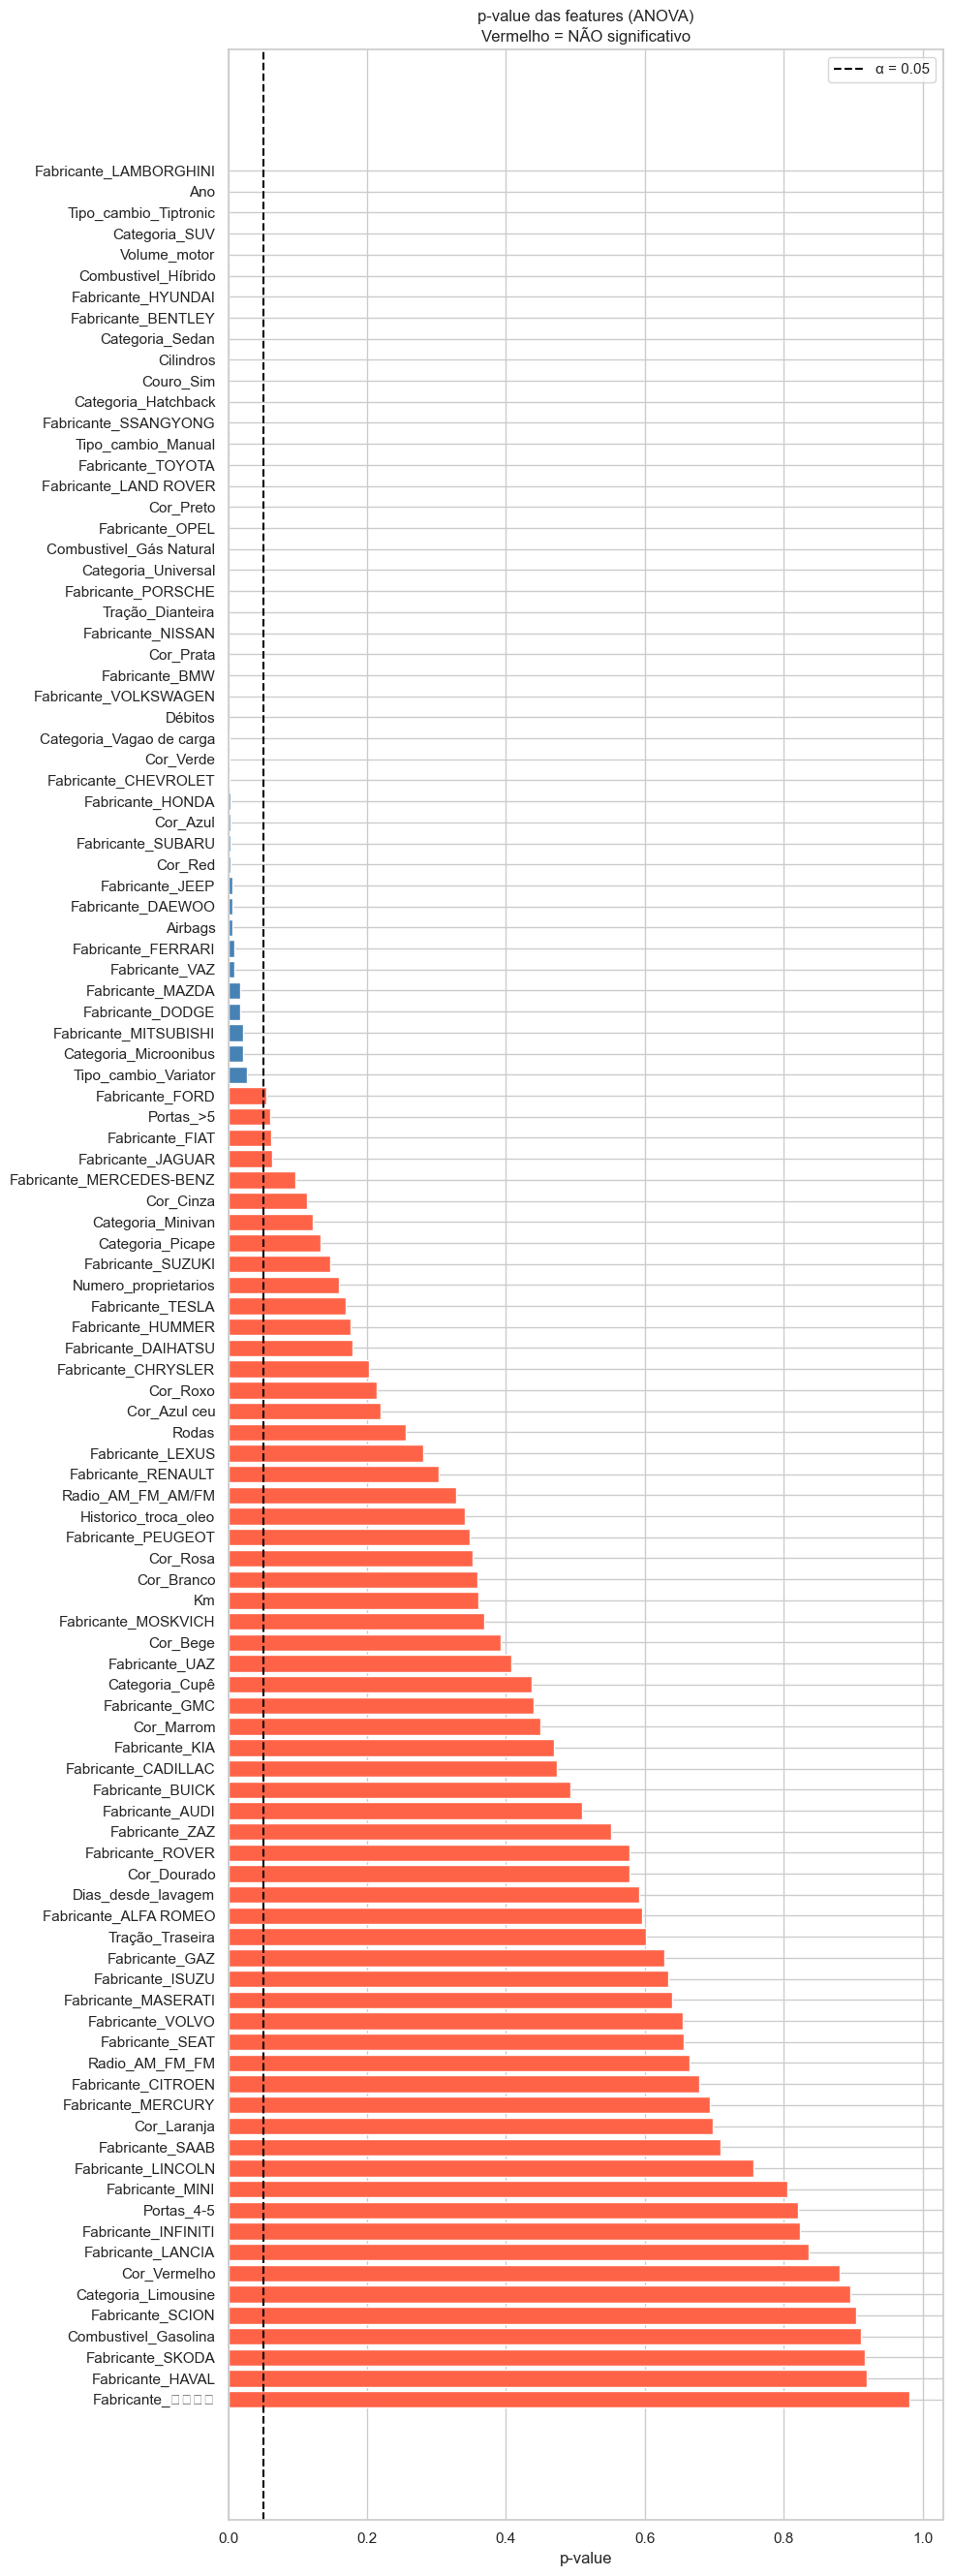

In [18]:
# --- Gráfico p-values ---
fig, ax = plt.subplots(figsize=(10, max(6, len(df_anova_result) * 0.25)))
cores_pv = ['tomato' if p > ALPHA else 'steelblue'
             for p in df_anova_result['p_value']]
ax.barh(df_anova_result['Feature'][::-1],
        df_anova_result['p_value'][::-1],
        color=cores_pv[::-1])
ax.axvline(ALPHA, color='black', linestyle='--', linewidth=1.5,
           label=f'α = {ALPHA}')
ax.set_xlabel('p-value')
ax.set_title('p-value das features (ANOVA)\nVermelho = NÃO significativo')
ax.legend()
plt.tight_layout()
plt.savefig('anova_pvalues.png', dpi=150)
plt.show()

## 11. Exportar dados tratados para o Notebook 2

Os dados exportados:
- Têm tipos corretos e categorias padronizadas
- **Não** tiveram outliers removidos (isso ocorre no Notebook 2)
- Incluem coluna auxiliar `Dias_desde_lavagem` se aplicável
- Mantêm todas as colunas originais para que o Notebook 2 possa decidir o que usar

In [19]:
# Salvar lista de colunas a remover (definidas pela ANOVA + identificadores)
import json

# Colunas identificadas como problemáticas / sem relevância estatística
# As features_remover aqui são os dummies; registramos as colunas *originais*
# Mapeamos de volta os prefixos de dummies para colunas originais
colunas_originais_remover = list(COLUNAS_REMOVER_EDA)  # já definidas acima

# Adicionar colunas originais cujos dummies ficaram todos não-significativos
for feat in features_remover:
    col_orig = feat.split('_')[0]  # heurística de prefixo
    # Verificar se nenhum dummy daquela coluna é significativo
    dummies_da_col = [f for f in X_anova.columns if f.startswith(col_orig + '_')]
    if dummies_da_col and all(
        df_anova_result.loc[df_anova_result['Feature'] == d, 'p_value'].values[0] > ALPHA
        for d in dummies_da_col if d in df_anova_result['Feature'].values
    ):
        if col_orig not in colunas_originais_remover:
            colunas_originais_remover.append(col_orig)

with open('database/anova_colunas_remover.json', 'w') as f:
    json.dump(colunas_originais_remover, f, ensure_ascii=False, indent=2)

print('Colunas a remover (salvas em anova_colunas_remover.json):')
for c in colunas_originais_remover:
    print(f'  - {c}')

Colunas a remover (salvas em anova_colunas_remover.json):
  - ID
  - Faixa_Preco
  - Classificacao_Veiculo
  - Modelo
  - Data_ultima_lavagem
  - Adesivos_personalizados
  - Codigo_concessionaria
  - Portas
  - Numero
  - Radio
  - Historico
  - Dias


In [20]:
# Salvar datasets tratados (sem remoção de outliers)
df_train.to_csv('database/train_processed.csv', index=False)
df_test.to_csv('database/test_processed.csv',  index=False)

print('Dados exportados com sucesso:')
print(f'  database/train_processed.csv  → {df_train.shape}')
print(f'  database/test_processed.csv   → {df_test.shape}')
print(f'  database/anova_colunas_remover.json')

Dados exportados com sucesso:
  database/train_processed.csv  → (8685, 27)
  database/test_processed.csv   → (17370, 26)
  database/anova_colunas_remover.json


## Resumo da Análise Exploratória

| Etapa | Resultado |
|-------|-----------|
| Dataset de treino | shape salvo acima |
| Colunas removidas (identificadores + ANOVA) | ver `anova_colunas_remover.json` |
| Features significativas (p ≤ 0.05) | ver seção 10 |
| Outliers removidos | **Nenhum** — feito no Notebook 2 |
| Saída para Notebook 2 | `train_processed.csv`, `test_processed.csv`, `anova_colunas_remover.json` |